# 4. Morphological Algorithms - Khu doi tuong dac biet trong anh

Notebook nay di theo pipeline day du: cai thu vien -> doc anh -> tao mask -> morphology -> inpaint -> luu ket qua.


In [2]:
# Chay 1 lan de dam bao du thu vien
%pip install -q opencv-python numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 6)

def show(title, img, cmap=None):
    plt.figure()
    if cmap is None:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()


## 1) Chon anh dau vao
- Dat anh can xu ly vao cung thu muc `7/` (vi du: `input.jpg`).
- Sua bien `IMAGE_PATH` ben duoi.


Image size (W x H): 275 x 183


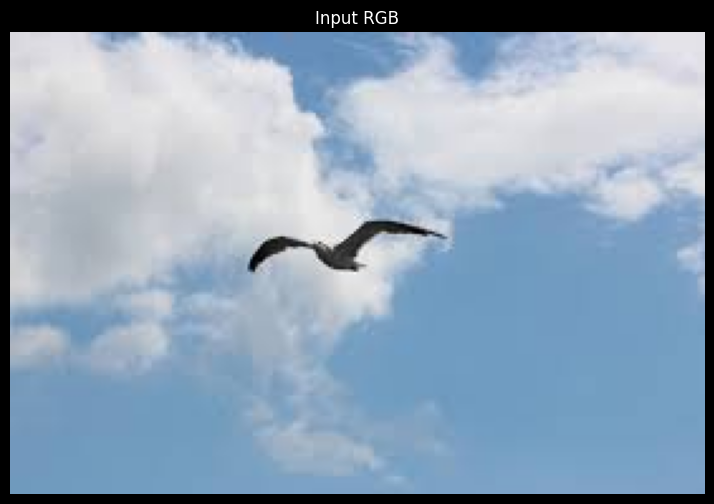

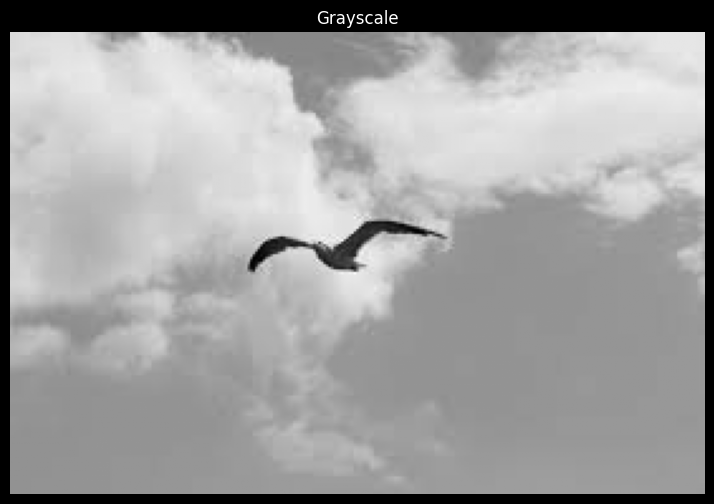

In [12]:
IMAGE_PATH = Path('input.jpg')  # doi ten file neu can
assert IMAGE_PATH.exists(), f'Khong tim thay anh: {IMAGE_PATH.resolve()}'

bgr = cv2.imread(str(IMAGE_PATH))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

print('Image size (W x H):', rgb.shape[1], 'x', rgb.shape[0])
show('Input RGB', rgb)
show('Grayscale', gray, cmap='gray')


## 2) Tao mask ban dau bang threshold
- `THRESH_BINARY_INV` thuong hop khi doi tuong can khu la chu/vet toi tren nen sang.
- Neu truong hop nguoc lai, doi sang `cv2.THRESH_BINARY`.


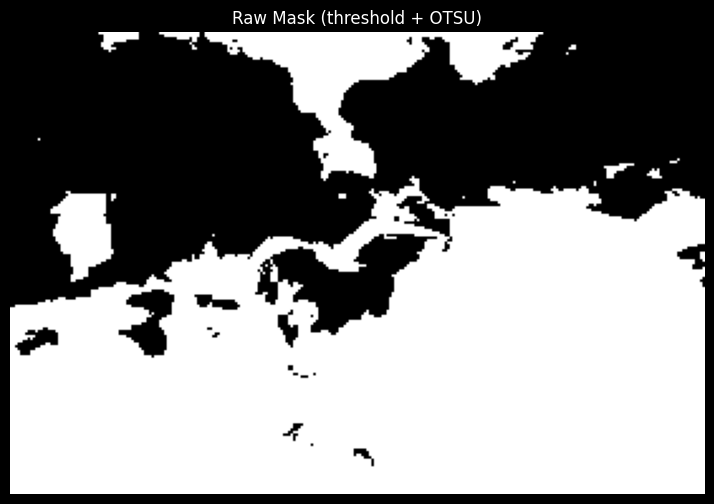

In [13]:
# Otsu tu tim nguong
_, raw_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
show('Raw Mask (threshold + OTSU)', raw_mask, cmap='gray')


## 3) Lam sach mask bang Morphology
- Opening: bo nhiu trang nho.
- Closing: lap lo den nho va lam lien khoi.


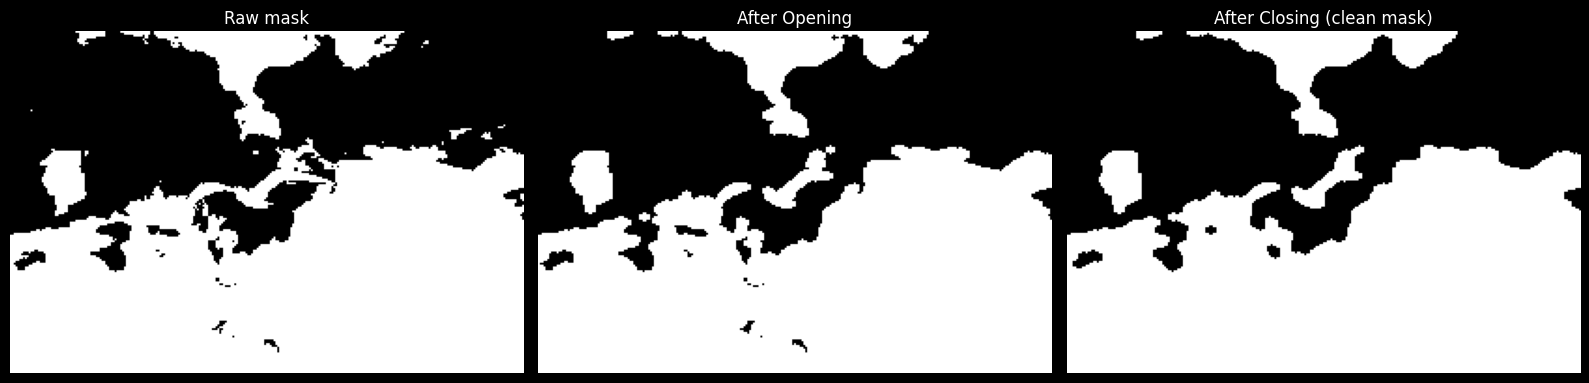

In [14]:
kernel_size = 5
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))

opened = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel, iterations=1)
clean_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(raw_mask, cmap='gray'); ax[0].set_title('Raw mask'); ax[0].axis('off')
ax[1].imshow(opened, cmap='gray'); ax[1].set_title('After Opening'); ax[1].axis('off')
ax[2].imshow(clean_mask, cmap='gray'); ax[2].set_title('After Closing (clean mask)'); ax[2].axis('off')
plt.tight_layout(); plt.show()


## 4) Loc bo doi tuong qua nho (tuy chon)
Buoc nay giup bo cac dom nhieu nho con sot lai trong mask.


So thanh phan (tru background): 5


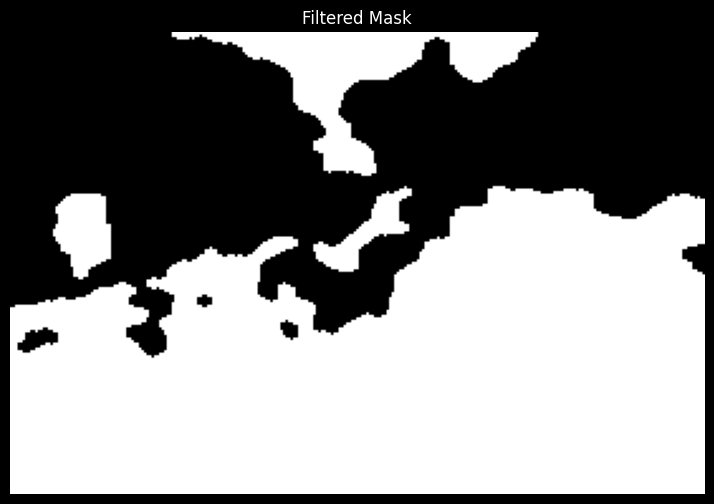

In [15]:
min_area = 120
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean_mask, connectivity=8)
filtered_mask = np.zeros_like(clean_mask)

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= min_area:
        filtered_mask[labels == i] = 255

print('So thanh phan (tru background):', num_labels - 1)
show('Filtered Mask', filtered_mask, cmap='gray')


## 5) Khu doi tuong va phuc hoi nen bang Inpainting
Mask cuoi cung duoc dua vao `cv2.inpaint` de dien lai vung bi xoa.


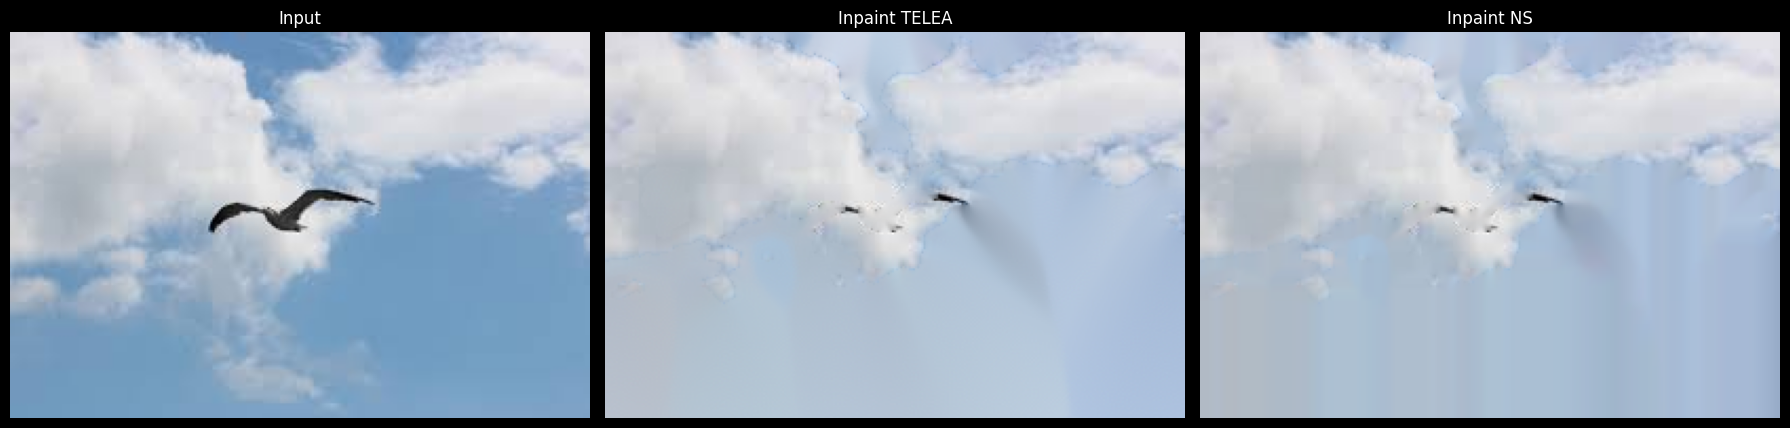

In [16]:
inpaint_radius = 5
result_telea = cv2.inpaint(bgr, filtered_mask, inpaint_radius, cv2.INPAINT_TELEA)
result_ns = cv2.inpaint(bgr, filtered_mask, inpaint_radius, cv2.INPAINT_NS)

result_telea_rgb = cv2.cvtColor(result_telea, cv2.COLOR_BGR2RGB)
result_ns_rgb = cv2.cvtColor(result_ns, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(rgb); ax[0].set_title('Input'); ax[0].axis('off')
ax[1].imshow(result_telea_rgb); ax[1].set_title('Inpaint TELEA'); ax[1].axis('off')
ax[2].imshow(result_ns_rgb); ax[2].set_title('Inpaint NS'); ax[2].axis('off')
plt.tight_layout(); plt.show()


## 6) Thu nghiem nhanh nhieu tham so
Cell nay giup tim bo tham so tot hon cho tung anh cu the.


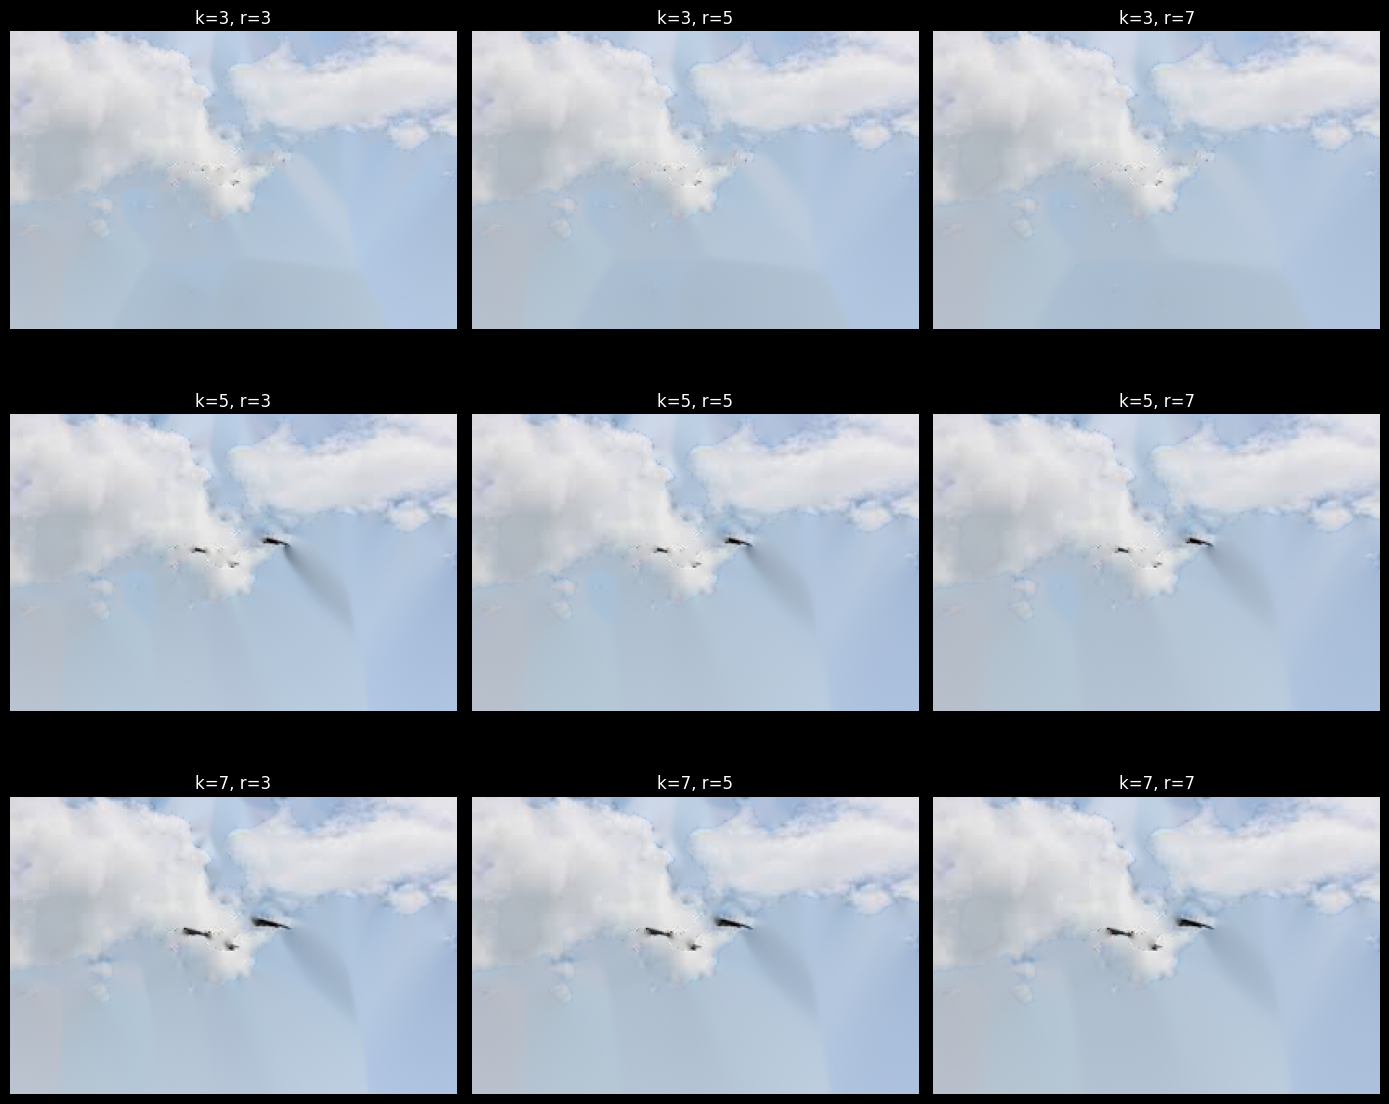

In [17]:
kernel_sizes = [3, 5, 7]
radii = [3, 5, 7]

fig, axes = plt.subplots(len(kernel_sizes), len(radii), figsize=(14, 12))
for i, ks in enumerate(kernel_sizes):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks, ks))
    m = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, k, iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=1)
    for j, r in enumerate(radii):
        out = cv2.inpaint(bgr, m, r, cv2.INPAINT_TELEA)
        out_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(out_rgb)
        axes[i, j].set_title(f'k={ks}, r={r}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()


## 7) Luu output
Chon ket qua ban thay dep nhat (TELEA hoac NS) de nop bai.


In [22]:
# Save selected parameters (default: k=3, r=3)\nselected_k = 3\nselected_r = 3\nselected_method = cv2.INPAINT_TELEA  # doi thanh cv2.INPAINT_NS neu can\n\nkernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (selected_k, selected_k))\nselected_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel, iterations=1)\nselected_mask = cv2.morphologyEx(selected_mask, cv2.MORPH_CLOSE, kernel, iterations=1)\nselected_result = cv2.inpaint(bgr, selected_mask, selected_r, selected_method)\n\nOUT_DIR = Path('outputs')\nOUT_DIR.mkdir(exist_ok=True)\nmethod_name = 'telea' if selected_method == cv2.INPAINT_TELEA else 'ns'\nmask_path = OUT_DIR / f'selected_k{selected_k}_r{selected_r}_{method_name}_mask.png'\nresult_path = OUT_DIR / f'selected_k{selected_k}_r{selected_r}_{method_name}_result.png'\ncv2.imwrite(str(mask_path), selected_mask)\ncv2.imwrite(str(result_path), selected_result)\nprint('Saved mask :', mask_path.resolve())\nprint('Saved image:', result_path.resolve())\n

In [21]:
OUT_DIR = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

cv2.imwrite(str(OUT_DIR / '01_raw_mask.png'), raw_mask)
cv2.imwrite(str(OUT_DIR / '02_clean_mask.png'), filtered_mask)
cv2.imwrite(str(OUT_DIR / '03_result_telea.png'), result_telea)
cv2.imwrite(str(OUT_DIR / '04_result_ns.png'), result_ns)

print('Da luu ket qua tai:', OUT_DIR.resolve())


Da luu ket qua tai: /mnt/h/20262027Period/Programming/Quarter2/Python/7/outputs


## 8) Goi y viet bao cao bai tap
- Mo ta doi tuong can khu (chu, logo, vet ban,...)
- Nguong threshold + loai kernel + kich thuoc kernel
- So sanh truoc/sau morphology
- So sanh TELEA vs NS
- Ket luan bo tham so tot nhat va ly do
